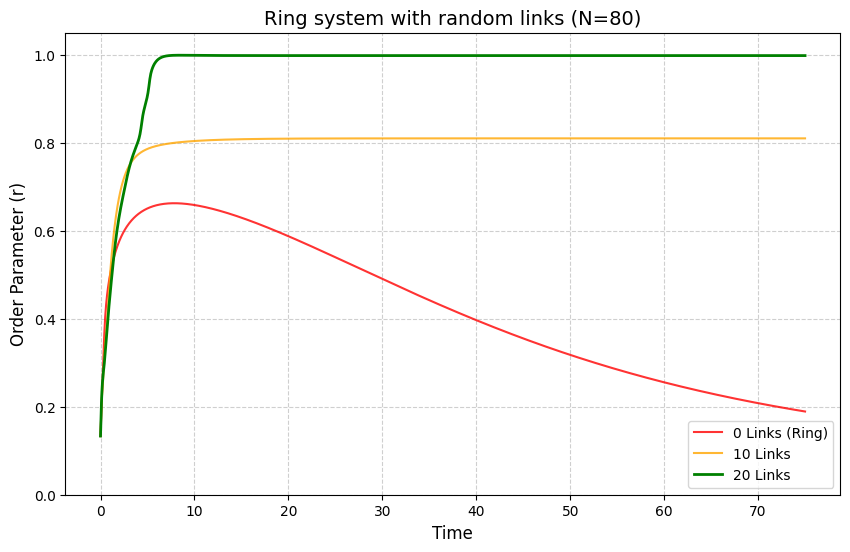

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def simulate_r(N, num_shortcuts, K=10.0, steps=1500, Dt=0.05):
    
    G = nx.cycle_graph(N)
    np.random.seed(10)
    added = 0
    while added < num_shortcuts:
        u, v = np.random.choice(range(N), 2, replace=False)
        if not G.has_edge(u, v):
            G.add_edge(u, v)
            added += 1
            
    
    np.random.seed(42)
    theta = np.random.uniform(0, 2*np.pi, N)
    omega = 2.0 + np.random.uniform(-0.2, 0.2, N)
    
    r_history = []
    for _ in range(steps):
        
        r = np.abs(np.mean(np.exp(1j * theta)))
        r_history.append(r)
        
        
        d_theta = np.zeros(N)
        for i in G.nodes():
            neighbors = list(G.neighbors(i))
            coupling = sum(np.sin(theta[j] - theta[i]) for j in neighbors) / len(neighbors)
            d_theta[i] = omega[i] + (K * coupling)
        theta += d_theta * Dt
        
    return r_history


N = 80
steps = 1500
t = np.linspace(0, steps * 0.05, steps)

r_0 = simulate_r(N, 0)
r_10 = simulate_r(N, 10)
r_20 = simulate_r(N, 20)


plt.figure(figsize=(10, 6))
plt.plot(t, r_0, label='0 Links (Ring)', color='red', alpha=0.8)
plt.plot(t, r_10, label='10 Links', color='orange', alpha=0.8)
plt.plot(t, r_20, label='20 Links', color='green', linewidth=2)

plt.title('Ring system with random links (N=80)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Order Parameter (r)', fontsize=12)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()